In [8]:
!pip install contractions

In [9]:
!pip install nltk

In [10]:
import nltk
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_r

True

In [11]:
!pip install pyspellchecker


In [12]:
import pandas as pd
from nltk.tokenize import word_tokenize,sent_tokenize
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import contractions
import re
from nltk.stem import WordNetLemmatizer
from spellchecker import SpellChecker
from nltk.corpus import stopwords
import seaborn as sns

In [111]:
df_train=pd.read_csv('/content/twitter_training.csv',header=None)
df_train.head()

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [112]:
df_train.rename({0:'id',1:'topic',2:'target',3:'text'},inplace=True,axis=1)
df_train.head()

,id,topic,target,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [113]:
df_train.shape

(74682, 4)

In [114]:
df_train.duplicated().sum()

np.int64(2700)

In [115]:
df_train.drop_duplicates(inplace=True)

In [116]:
df_train.shape

(71982, 4)

In [117]:
df_train.isnull().sum()

,0
id,0
topic,0
target,0
text,326


In [118]:
df_train.dropna(inplace=True)

In [119]:
df_train.head()

,id,topic,target,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [120]:
cnt=df_train['topic'].value_counts()

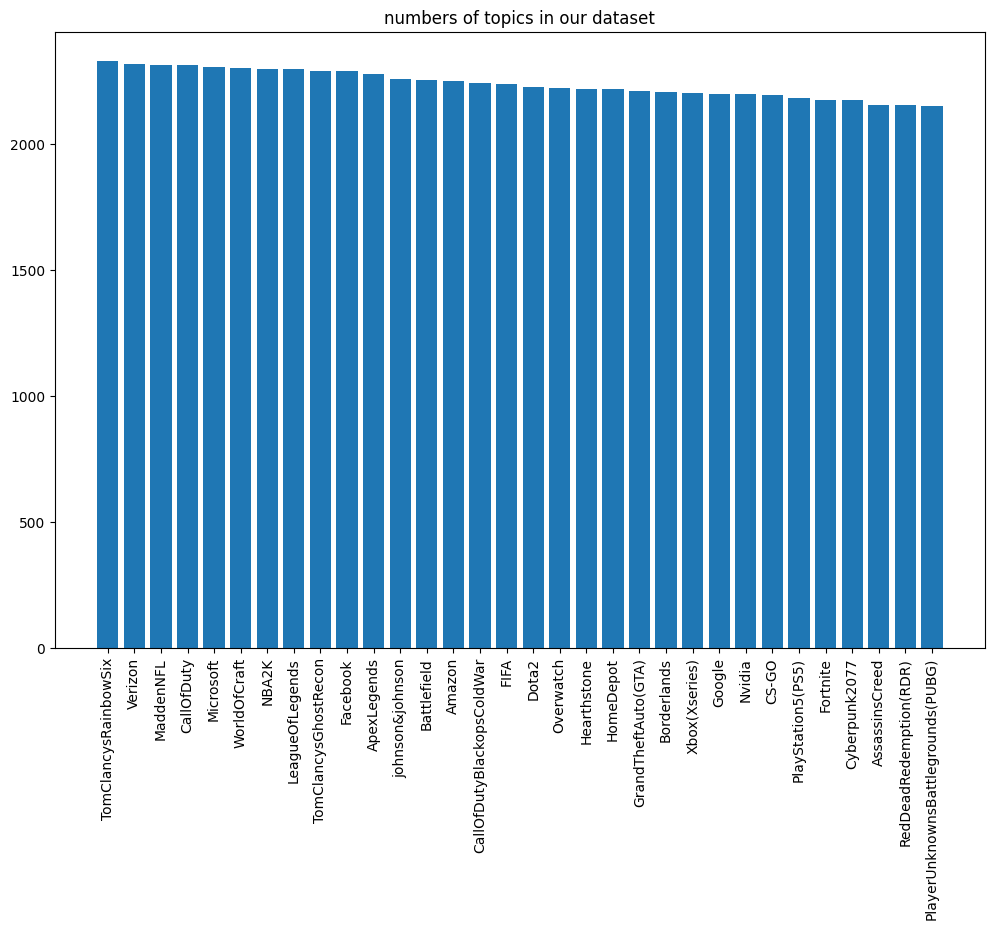

In [121]:
plt.figure(figsize=(12,8))
plt.title('numbers of topics in our dataset')
plt.bar(x=cnt.index,height=cnt.values)
plt.xticks(rotation=90)
plt.show()

In [122]:
df_train.drop(['id','topic'],axis=1,inplace=True)

In [123]:
df_train.head()

,target,text
0,Positive,im getting on borderlands and i will murder yo...
1,Positive,I am coming to the borders and I will kill you...
2,Positive,im getting on borderlands and i will kill you ...
3,Positive,im coming on borderlands and i will murder you...
4,Positive,im getting on borderlands 2 and i will murder ...


In [124]:
cnt_target=df_train['target'].value_counts()

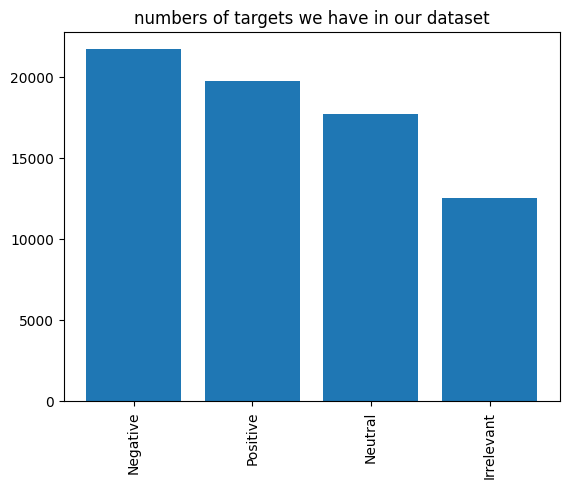

In [125]:
plt.title('numbers of targets we have in our dataset')
plt.bar(x=cnt_target.index,height=cnt_target.values)
plt.xticks(rotation=90)
plt.show()

In [126]:
df_train["No_of_Characters"] = df_train["text"].apply(len)
df_train["No_of_Words"]=df_train.apply(lambda row: word_tokenize(row["text"]), axis=1).apply(len)
df_train["No_of_sentence"]=df_train.apply(lambda row: sent_tokenize(row["text"]), axis=1).apply(len)

In [127]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
No_of_Characters,71656.0,110.538127,79.409848,1.0,49.0,93.0,155.0,957.0
No_of_Words,71656.0,22.972535,17.163287,0.0,10.0,19.0,32.0,198.0
No_of_sentence,71656.0,1.954491,1.638269,0.0,1.0,1.0,2.0,33.0


In [128]:
df_train['target'].unique()

array(['Positive', 'Neutral', 'Negative', 'Irrelevant'], dtype=object)

In [129]:
df_train['target']=df_train['target'].map({'Positive':0,'Neutral':1,'Negative':2,'Irrelevant':3})

In [130]:
df_train.head()

,target,text,No_of_Characters,No_of_Words,No_of_sentence
0,0,im getting on borderlands and i will murder yo...,53,11,1
1,0,I am coming to the borders and I will kill you...,51,13,1
2,0,im getting on borderlands and i will kill you ...,50,11,1
3,0,im coming on borderlands and i will murder you...,51,11,1
4,0,im getting on borderlands 2 and i will murder ...,57,13,1


<Axes: >

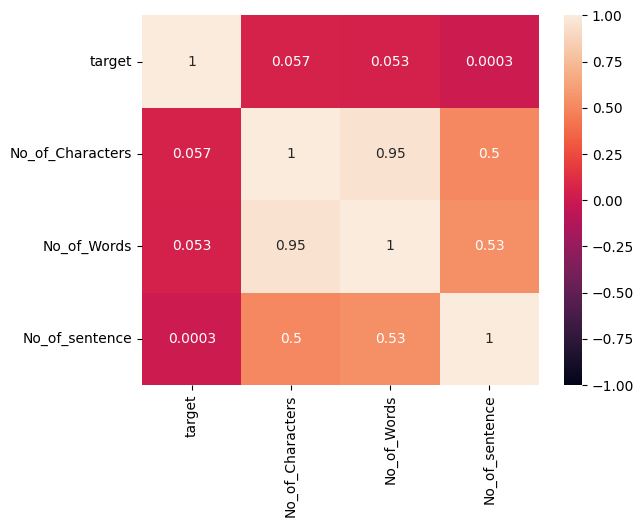

In [131]:
sns.heatmap(df_train.drop('text',axis=1).corr(),annot=True,vmin=-1,vmax=1)

In [132]:
df_train=df_train[['target','text']]

In [133]:
df_train.head()

,target,text
0,0,im getting on borderlands and i will murder yo...
1,0,I am coming to the borders and I will kill you...
2,0,im getting on borderlands and i will kill you ...
3,0,im coming on borderlands and i will murder you...
4,0,im getting on borderlands 2 and i will murder ...


In [134]:
stopwords_en=stopwords.words('english')
print(stopwords_en)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [135]:
# Define negative words to keep
negative_words = {"no", "not", "never", "none", "n't"}
stopwords_en=set(stopwords_en)
# Remove negative words from stop_words
custom_stop_words = stopwords_en - negative_words

print("Original stop words length:", len(stopwords_en))
print("Custom stop words length:", len(custom_stop_words))

Original stop words length: 198
Custom stop words length: 196


In [136]:
lemmatizer=WordNetLemmatizer()
spell = SpellChecker(language='en')

def clean_text(text):

    text = contractions.fix(text)

    # Remove punctuation, symbols, numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Lowercase
    text = text.lower()

    # Tokenize
    words = word_tokenize(text)

    # Remove stopwords & short tokens
    filtered = [w for w in words if w not in custom_stop_words and len(w) > 1]

    # filtered = [spell.correction(w) if len(w) > 0 else w for w in filtered]

    # Lemmatize
    lemmatized = [lemmatizer.lemmatize(w) for w in filtered]

    # Rejoin and normalize spaces
    cleaned = " ".join(lemmatized)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()

    return cleaned

In [137]:
from tqdm import tqdm
tqdm.pandas()

In [138]:
df_train['text']=df_train['text'].astype(str)

In [139]:
back_df=df_train.copy()

In [140]:
df_train['text']=df_train['text'].progress_apply(clean_text)

100%|██████████| 71656/71656 [00:11<00:00, 6219.78it/s]


In [141]:
df_train['text']

,text
0,getting borderland murder
1,coming border kill
2,getting borderland kill
3,coming borderland murder
4,getting borderland murder
...,...
74677,realized window partition mac like year behind...
74678,realized mac window partition year behind nvid...
74679,realized window partition mac year behind nvid...
74680,realized window partition mac like year behind...


In [142]:
df_train.to_csv('twitter_training_cleaned.csv',index=False)

In [143]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding,Dense,SimpleRNN,LSTM,Dropout,BatchNormalization,Bidirectional
from tensorflow.keras.models import Sequential

In [144]:
df_train=pd.read_csv('twitter_training_cleaned.csv')
df_train.head()

,target,text
0,0,getting borderland murder
1,0,coming border kill
2,0,getting borderland kill
3,0,coming borderland murder
4,0,getting borderland murder


In [145]:
df_train = df_train.sample(frac=1, random_state=42)
df_train.head()

,target,text
50649,0,red dead redemption arguably best grossing gam...
4066,1,release black weapon ops cold war stuff right ...
33863,0,edge chromium good news privacy conscious folk...
50829,3,bully may dooed live grand theft auto red dead...
38291,0,started getting back playing battlefield hardl...


In [146]:
df_train.dtypes

,0
target,int64
text,object


In [221]:
df_train['text']=df_train['text'].astype(str)
tok=Tokenizer(15_000,oov_token="<OOV>")
tok.fit_on_texts(df_train['text'])

In [222]:
word_ind=tok.word_index
print(word_ind)

{'<OOV>': 1, 'not': 2, 'game': 3, 'com': 4, 'like': 5, 'get': 6, 'pic': 7, 'twitter': 8, 'one': 9, 'play': 10, 'good': 11, 'time': 12, 'no': 13, 'love': 14, 'really': 15, 'new': 16, 'unk': 17, 'people': 18, 'johnson': 19, 'see': 20, 'shit': 21, 'co': 22, 'going': 23, 'player': 24, 'best': 25, 'got': 26, 'go': 27, 'still': 28, 'facebook': 29, 'u': 30, 'year': 31, 'http': 32, 'day': 33, 'would': 34, 'amazon': 35, 'make': 36, 'great': 37, 'even': 38, 'playing': 39, 'xbox': 40, 'google': 41, 'look': 42, 'know': 43, 'fucking': 44, 'microsoft': 45, 'rhandlerr': 46, 'fuck': 47, 'please': 48, 'want': 49, 'dead': 50, 'verizon': 51, 'p': 52, 'back': 53, 'much': 54, 'fifa': 55, 'red': 56, 'guy': 57, 'first': 58, 'tv': 59, 'home': 60, 'video': 61, 'today': 62, 'nvidia': 63, 'pubg': 64, 'nan': 65, 'fun': 66, 'say': 67, 'call': 68, 'borderland': 69, 'also': 70, 'gta': 71, 'thing': 72, 'team': 73, 'fix': 74, 'ban': 75, 'right': 76, 'nba': 77, 'world': 78, 'ever': 79, 'work': 80, 'bad': 81, 'twitch': 

In [223]:
import numpy as np
sequences = tok.texts_to_sequences(df_train['text'])
lengths = [len(s) for s in sequences]
np.percentile(lengths, [90])

array([23.])

In [224]:
padded_sequences = pad_sequences(sequences, maxlen=23 ,padding='post')

In [225]:
import numpy as np
y = np.array(df_train['target'])

In [226]:
from tensorflow.keras.regularizers import l2

In [254]:
import tensorflow as tf
from tensorflow.keras import backend as K

def recall_m(y_true, y_pred):
    y_pred = tf.one_hot(tf.argmax(y_pred, axis=-1), depth=tf.shape(y_pred)[-1])
    y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[-1])

    tp = tf.reduce_sum(y_true * y_pred, axis=0)
    fn = tf.reduce_sum(y_true * (1 - y_pred), axis=0)
    recall = tp / (tp + fn + K.epsilon())
    return tf.reduce_mean(recall)

def precision_m(y_true, y_pred):
    y_pred = tf.one_hot(tf.argmax(y_pred, axis=-1), depth=tf.shape(y_pred)[-1])
    y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[-1])

    tp = tf.reduce_sum(y_true * y_pred, axis=0)
    fp = tf.reduce_sum((1 - y_true) * y_pred, axis=0)
    precision = tp / (tp + fp + K.epsilon())
    return tf.reduce_mean(precision)

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2 * ((precision * recall) / (precision + recall + K.epsilon()))


In [260]:
from tensorflow.keras.regularizers import l2

In [294]:
tf.random.set_seed(42)

embedding_dim = 256

model = Sequential([
    Embedding(input_dim=len(word_ind)+1, output_dim=embedding_dim, input_length=padded_sequences.shape[1]),

    LSTM(128,return_sequences=False,dropout=0.3,recurrent_dropout=0.3),
    # LSTM(128,dropout=0.3,recurrent_dropout=0.3),
    Dropout(0.3),

    Dense(64,activation='relu'),
    Dropout(0.3),

    Dense(16,activation='relu'),
    Dropout(0.3),

    Dense(4, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy',recall_m,precision_m,f1_m])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_30 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_45 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [295]:
from tensorflow.keras.callbacks import EarlyStopping

er=EarlyStopping(patience=5,restore_best_weights=True)

In [296]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
class_weights = dict(zip(classes, class_weights))
print(class_weights)


{np.int64(0): np.float64(0.9087404251001877), np.int64(1): np.float64(1.0116331601536028), np.int64(2): np.float64(0.8256060466402433), np.int64(3): np.float64(1.4288904841668661)}


In [297]:
model.fit(padded_sequences, y, epochs=50, batch_size=256,validation_split=0.2,callbacks=[er],class_weight=class_weights)

Epoch 1/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 27s 100ms/step - accuracy: 0.3105 - f1_m: 0.3039 - loss: 1.3484 - precision_m: 0.3060 - recall_m: 0.3030 - val_accuracy: 0.5144 - val_f1_m: 0.5354 - val_loss: 0.9908 - val_precision_m: 0.5345 - val_recall_m: 0.5367
Epoch 2/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 39s 93ms/step - accuracy: 0.5668 - f1_m: 0.5590 - loss: 0.9923 - precision_m: 0.5627 - recall_m: 0.5556 - val_accuracy: 0.6672 - val_f1_m: 0.6491 - val_loss: 0.7978 - val_precision_m: 0.6508 - val_recall_m: 0.6475
Epoch 3/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 22s 96ms/step - accuracy: 0.7006 - f1_m: 0.6916 - loss: 0.7605 - precision_m: 0.7005 - recall_m: 0.6831 - val_accuracy: 0.7747 - val_f1_m: 0.7723 - val_loss: 0.6505 - val_precision_m: 0.7809 - val_recall_m: 0.7640
Epoch 4/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 22s 100ms/step - accuracy: 0.8005 - f1_m: 0.8005 - loss: 0.5719 - precision_m: 0.8118 - recall_m: 0.7897 - val_accuracy: 0.8062 - val_f1_m: 0.8105 - val_loss: 0.5632 - val_precision_m: 0.8194 - val

In [298]:
model.save('lstm_twitter.h5')